In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

In [3]:
df = pd.read_csv("../data/final_engineered_data.csv")

print(df.head())

   Year  Selling_Price  Present_Price  Kms_Driven  Owner  Car_Age  \
0  2014           3.35           5.59       27000      0       12   
1  2013           4.75           9.54       43000      0       13   
2  2017           7.25           9.85        6900      0        9   
3  2011           2.85           4.15        5200      0       15   
4  2014           4.60           6.87       42450      0       12   

   Mileage_per_Year  Log_Selling_Price  Log_Kms_Driven  Fuel_Type_Diesel  ...  \
0       2250.000000           1.208960       10.203592             False  ...   
1       3307.692308           1.558145       10.668955              True  ...   
2        766.666667           1.981001        8.839277             False  ...   
3        346.666667           1.047319        8.556414             False  ...   
4       3537.500000           1.526056       10.656082              True  ...   

   Transmission_Manual  Age_Group_Medium  Age_Group_Old  \
0                 True             Fals

In [4]:
X = df.drop('Selling_Price', axis=1)

y = df['Selling_Price']

print(X.shape)

print(y.shape)

(301, 21)
(301,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(240, 21)
(61, 21)
(240,)
(61,)


In [6]:
numeric_df = X_train.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

print(corr_matrix)

                       Year  Present_Price  Kms_Driven     Owner   Car_Age  \
Year               1.000000      -0.035695   -0.510738 -0.199157 -1.000000   
Present_Price     -0.035695       1.000000    0.185208  0.023516  0.035695   
Kms_Driven        -0.510738       0.185208    1.000000  0.093830  0.510738   
Owner             -0.199157       0.023516    0.093830  1.000000  0.199157   
Car_Age           -1.000000       0.035695    0.510738  0.199157  1.000000   
Mileage_per_Year  -0.361667       0.237943    0.965293  0.043258  0.361667   
Log_Selling_Price  0.306741       0.690966   -0.024104 -0.096922 -0.306741   
Log_Kms_Driven    -0.527941       0.287843    0.688035  0.079942  0.527941   
Depreciation      -0.290568       0.882102    0.298592  0.131224  0.290568   

                   Mileage_per_Year  Log_Selling_Price  Log_Kms_Driven  \
Year                      -0.361667           0.306741       -0.527941   
Present_Price              0.237943           0.690966        0.287843 

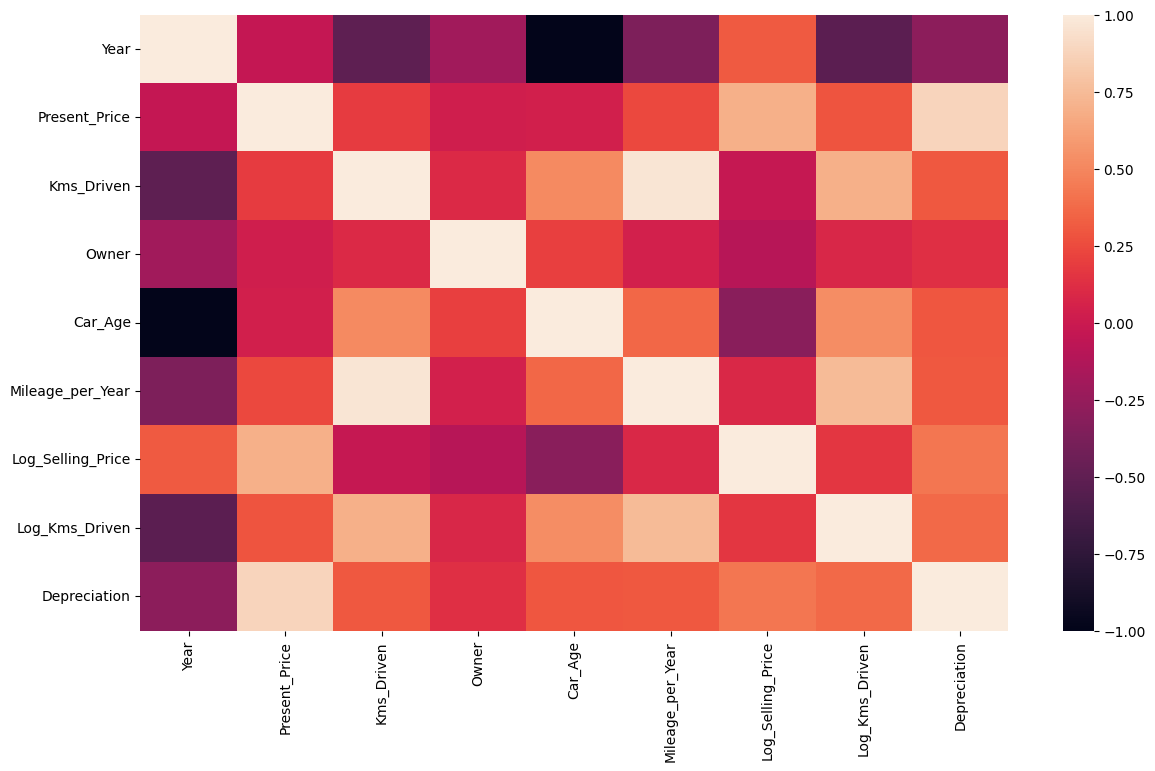

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))

sns.heatmap(corr_matrix, annot=False)

plt.show()

In [8]:
scaler = StandardScaler()
numeric_features = X_train.select_dtypes(include=['number']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ]
)
X_train_scaled = preprocessor.fit_transform(X_train)

X_test_scaled = preprocessor.transform(X_test)
print(X_train_scaled.shape)

print(X_test_scaled.shape)

(240, 9)
(61, 9)


In [9]:
pd.DataFrame(X_train_scaled).to_csv(
    "../data/X_train_scaled.csv",
    index=False
)

pd.DataFrame(X_test_scaled).to_csv(
    "../data/X_test_scaled.csv",
    index=False
)

y_train.to_csv(
    "../data/y_train.csv",
    index=False
)

y_test.to_csv(
    "../data/y_test.csv",
    index=False
)

In [10]:
from sklearn.model_selection import KFold
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(kf)

KFold(n_splits=5, random_state=42, shuffle=True)


In [11]:
print(X_train_scaled[:5])

[[-1.96986094 -0.75359579 -0.27555466  3.52821143  1.96986094 -0.57036432
  -1.77029735  0.0501538  -0.47513783]
 [ 1.15644297 -0.73130669 -0.81428242 -0.18569534 -1.15644297 -1.00294816
  -0.91650986 -1.90243422 -0.53528894]
 [-1.96986094 -0.7494723   0.29908829 -0.18569534  1.96986094 -0.02394262
  -1.94371355  0.68688028 -0.457694  ]
 [ 0.46170877 -0.07935058 -0.0361201  -0.18569534 -0.46170877  0.17889574
   0.37464676  0.36701673 -0.0039541 ]
 [ 0.80907587 -0.67001167 -0.68977645 -0.18569534 -0.80907587 -0.805781
  -0.58432138 -1.01582429 -0.50521338]]


In [12]:
from sklearn.linear_model import LinearRegression
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

print(y_pred[:5])

[ 0.35 10.11  4.95  0.15  6.95]


In [13]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)

print(score)

1.0


In [14]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison.head(10))

     Actual  Predicted
177    0.35       0.35
289   10.11      10.11
228    4.95       4.95
198    0.15       0.15
60     6.95       6.95
9      7.45       7.45
118    1.10       1.10
154    0.50       0.50
164    0.45       0.45
33     6.00       6.00


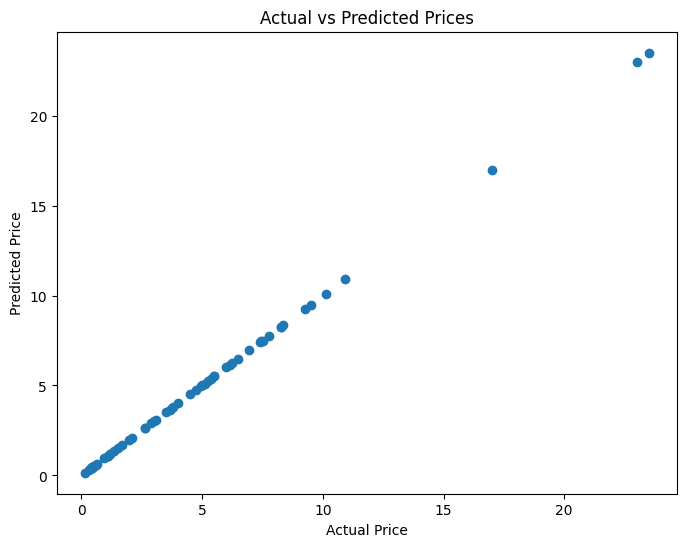

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

In [16]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)

print(mae)

3.845284746355409e-15


In [17]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)

print(mse)

2.36405311718526e-29


In [18]:
rmse = np.sqrt(mse)

print(rmse)

4.8621529358765134e-15


In [19]:
import joblib
joblib.dump(model_pipeline, "../src/car_price_model.pkl")
loaded_model = joblib.load("../src/car_price_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully
